In [1]:
#Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("balanced_synthetic_iot_data.csv")

# Check dataset
print(df.head())


   temperature   humidity          gas  anomaly
0    23.959044  42.622617   335.279916      0.0
1    66.066941  95.490659  1156.418347      1.0
2    23.447945  32.743708   314.865849      0.0
3    20.048388  55.340437   317.108755      0.0
4    20.512333  55.210241   274.369399      0.0


In [18]:
# Step 2: Preprocess the Data

# Select relevant features
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("balanced_synthetic_iot_data.csv")

# Separate features and labels
features = ["temperature", "humidity", "gas"]
X = df[features].values
y = df["anomaly"].values  # y is your target labels

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets (if not done already)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")




Training Data Shape: (1000, 3)
Testing Data Shape: (250, 3)


In [4]:
# Step 3: Build the Autoencoder Model

# Define Autoencoder
input_dim = X_train.shape[1]

autoencoder = keras.Sequential([
    keras.Input(shape=(input_dim,)),  # Explicitly define input layer
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(input_dim, activation="sigmoid")  # Output same size as input
])

# Compile model
autoencoder.compile(optimizer="adam", loss="mse")

# Model summary
autoencoder.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 395 (1.54 KB)

 Trainable params: 395 (1.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0840 - val_loss: 0.0918
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0710 - val_loss: 0.0904
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0554 - val_loss: 0.0962
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0329 - val_loss: 0.1155
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0155 - val_loss: 0.1271
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0087 - val_loss: 0.1307
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0064 - val_loss: 0.1333
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0062 - val_loss: 0.1329
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0056 - val_loss: 0.1341
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0052 - val_loss: 0.1328
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0049 - val_loss: 0.1325
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

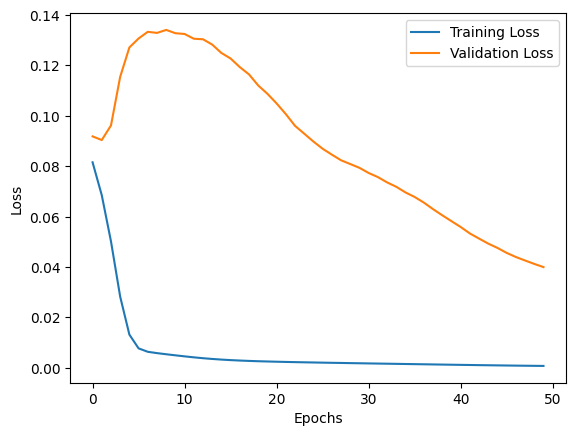

In [11]:
#Step 4: Train the Model

# Train only on normal data
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define Autoencoder Model
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Define input shape here
    Dense(8, activation="relu"),
    Dense(16, activation="relu"),
    Dense(X_train.shape[1], activation="sigmoid")  # Reconstruct input
])

# Compile the model
model.compile(optimizer="adam", loss="mse")

# Train the model
history = model.fit(X_train, X_train, 
                    epochs=50, batch_size=32, 
                    validation_data=(X_test, X_test),
                    verbose=1)



# Plot training loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 


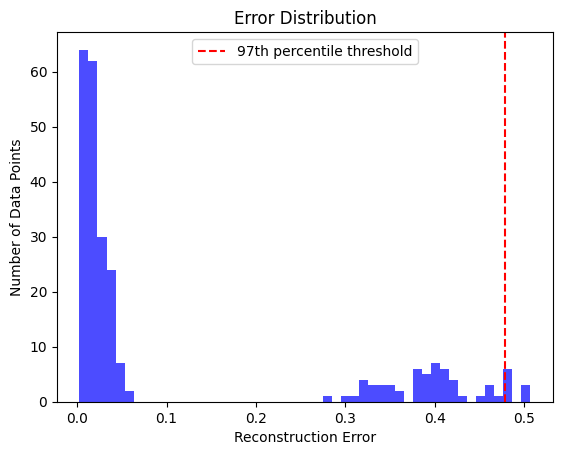

✅ New Threshold for Anomalies: 0.47873000000360916
⚠️ False Positives After Adjustment: 0
✅ True Anomalies Detected: 8


In [16]:
#Step 5: Detect Anomalies &Adjust the Anomaly Threshold

import numpy as np
import matplotlib.pyplot as plt

# Calculate reconstruction errors
reconstruction_errors = np.mean(np.abs(X_test - model.predict(X_test)), axis=1)

# Visualize error distribution
plt.hist(reconstruction_errors, bins=50, alpha=0.7, color='blue')
plt.axvline(np.percentile(reconstruction_errors, 97), color='red', linestyle='dashed', label="97th percentile threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Data Points")
plt.title("Error Distribution")
plt.legend()
plt.show()

# Automatically determine a better threshold (adjust percentile if needed)
new_threshold = np.percentile(reconstruction_errors, 97)  # Adjusting to 97th percentile

print(f"✅ New Threshold for Anomalies: {new_threshold}")

# Detect anomalies based on the new threshold
predicted_anomalies = reconstruction_errors > new_threshold

# Count false positives
false_positives = ((y_test == 0) & (predicted_anomalies == True)).sum()
print(f"⚠️ False Positives After Adjustment: {false_positives}")

# Count true anomalies detected
true_positives = ((y_test == 1) & (predicted_anomalies == True)).sum()
print(f"✅ True Anomalies Detected: {true_positives}")



In [20]:
model.save("autoencoder_model.keras")

